<a href="https://colab.research.google.com/github/dhanwariagarvit21/cont-s-stylized-facts/blob/main/volatility_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pdf
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats
import datetime

In [9]:

end_date_onem = datetime.date.today()
start_date_onem = end_date_onem - datetime.timedelta(days=5)
start_date_oned = datetime.date(2025, 2, 14)
end_date_oned = datetime.date(2026, 2, 14)

onem_data = yf.download('^NSEI', start=start_date_onem, end=end_date_onem, interval="1m")["Close"].squeeze()
oned_data = yf.download('^NSEI', start=start_date_oned, end=end_date_oned)["Close"].squeeze()

onem_returns = onem_data.pct_change().dropna()
oned_returns = oned_data.pct_change().dropna()

def manual_acf(series, lags=10):
    series = np.array(series)
    n = len(series)
    if n == 0:
        return np.full(lags + 1, np.nan)
    mean = series.mean()
    denominator = np.sum((series - mean) ** 2)
    if denominator == 0:
        return np.full(lags + 1, np.nan)
    acf_values = [1.0]
    for k in range(1, lags + 1):
        if k >= n:
            acf_values.append(np.nan)
        else:
            numerator = np.sum((series[k:] - mean) * (series[:-k] - mean))
            acf_values.append(numerator / denominator)
    return np.array(acf_values)

LAGS = 10
acf_1m = manual_acf(onem_returns, LAGS)
acf_1d = manual_acf(oned_returns, LAGS)
ci_1m = 1.96 / np.sqrt(len(onem_returns)) if len(onem_returns) > 0 else np.inf
ci_1d = 1.96 / np.sqrt(len(oned_returns)) if len(oned_returns) > 0 else np.inf

print(f"{'Lag':<6} {'ACF 1-min':>12} {'ACF 1-day':>12}")
print("-" * 32)
for i in range(1, LAGS + 1):
    sig_1m = "*" if not np.isnan(acf_1m[i]) and not np.isinf(ci_1m) and abs(acf_1m[i]) > ci_1m else ""
    sig_1d = "*" if not np.isnan(acf_1d[i]) and not np.isinf(ci_1d) and abs(acf_1d[i]) > ci_1d else ""
    print(f"{i:<6} {acf_1m[i]:>11.4f}{sig_1m:<1} {acf_1d[i]:>11.4f}{sig_1d:<1}")

print(f"\n95% CI bands:  1-min ±{ci_1m:.4f}  |  1-day ±{ci_1d:.4f}")
print("* = significant at 5% level")

/tmp/ipykernel_3635/1893523580.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  onem_data = yf.download('^NSEI', start=start_date_onem, end=end_date_onem, interval="1m")["Close"].squeeze()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3635/1893523580.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oned_data = yf.download('^NSEI', start=start_date_oned, end=end_date_oned)["Close"].squeeze()
[*********************100%***********************]  1 of 1 completed

Lag       ACF 1-min    ACF 1-day
--------------------------------
1          -0.0142       0.0186 
2           0.0142       0.0237 
3          -0.0229       0.0661 
4          -0.0338      -0.0332 
5          -0.0480      -0.0600 
6          -0.0028      -0.0845 
7          -0.0446      -0.0203 
8           0.0636*     -0.1520*
9           0.0020       0.0133 
10          0.0423      -0.0737 

95% CI bands:  1-min ±0.0506  |  1-day ±0.1252
* = significant at 5% level


### Autocorrelation of Squared Returns (Volatility Clustering)

In [10]:

onem_returns_sq = onem_returns**2
oned_returns_sq = oned_returns**2
acf_1m_sq = manual_acf(onem_returns_sq, LAGS)
acf_1d_sq = manual_acf(oned_returns_sq, LAGS)
ci_1m_sq = 1.96 / np.sqrt(len(onem_returns_sq))
ci_1d_sq = 1.96 / np.sqrt(len(oned_returns_sq))

print(f"{'Lag':<6} {'ACF 1-min Sq':>12} {'ACF 1-day Sq':>12}")
print("-" * 40)
for i in range(1, LAGS + 1):
    sig_1m_sq = "*" if abs(acf_1m_sq[i]) > ci_1m_sq else ""
    sig_1d_sq = "*" if abs(acf_1d_sq[i]) > ci_1d_sq else ""
    print(f"{i:<6} {acf_1m_sq[i]:>11.4f}{sig_1m_sq:<1} {acf_1d_sq[i]:>11.4f}{sig_1d:<1}")

print(f"\n95% CI bands:  1-min Sq ±{ci_1m_sq:.4f}  |  1-day Sq ±{ci_1d_sq:.4f}")
print("* = significant at 5% level")

Lag    ACF 1-min Sq ACF 1-day Sq
----------------------------------------
1           0.0131       0.1887 
2           0.0002       0.0224 
3           0.0036       0.1877 
4           0.0038       0.1370 
5           0.0046      -0.0028 
6          -0.0018       0.0619 
7           0.0046       0.0131 
8           0.0041       0.0164 
9          -0.0003       0.0919 
10          0.0050       0.0231 

95% CI bands:  1-min Sq ±0.0506  |  1-day Sq ±0.1252
* = significant at 5% level


### Plotting ACF of Squared Returns

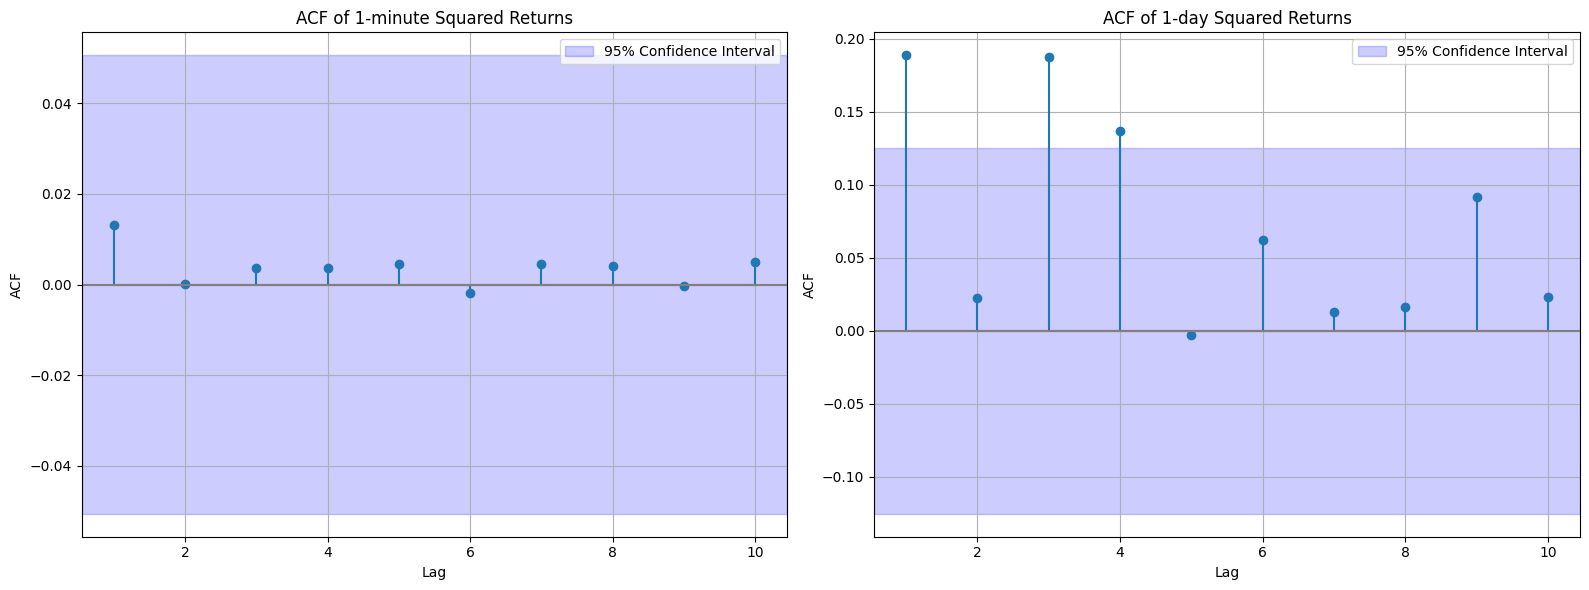

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].stem(range(1, LAGS + 1), acf_1m_sq[1:])
axes[0].axhline(y=0, color='gray', linestyle='-')
axes[0].axhspan(-ci_1m_sq, ci_1m_sq, alpha=0.2, color='blue', label='95% Confidence Interval')
axes[0].set_title('ACF of 1-minute Squared Returns')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('ACF')
axes[0].legend()
axes[0].grid(True)
axes[1].stem(range(1, LAGS + 1), acf_1d_sq[1:])
axes[1].axhline(y=0, color='gray', linestyle='-')
axes[1].axhspan(-ci_1d_sq, ci_1d_sq, alpha=0.2, color='blue', label='95% Confidence Interval')
axes[1].set_title('ACF of 1-day Squared Returns')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('ACF')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()